---
title: Umbra Processing Workflow
description: This notebook demonstrates the complete workflow for downloading and processing Umbra SAR imagery using the `disasters-product-algorithms` package. 
author: 
  - Ethan Kerr (Editor, UAH)
  - Kyle Lesinger (Editor, UAH)
date: May 12, 2026
execute:
   freeze: true
---

# Run This Notebook

<div class="alert alert-block" style="
     background-color: #f8d7da;
     color: #721c24;
     border-left: 4px solid #28a745;
  ">
Disclaimer: it is highly recommended to run a tutorial within NASA VEDA JupyterHub, which already includes functions for processing and visualizing data specific to VEDA stories. Running the tutorial outside of the VEDA JupyterHub may lead to errors, specifically related to EarthData authentication. Additionally, it is recommended to use the Pangeo workspace within the VEDA JupyterHub, since certain packages relevant to this tutorial are already installed. </div>

<h4> If you <strong>do not</strong> have a VEDA Jupyterhub Account you can launch this notebook on your local environment using MyBinder by clicking the icon below.</h4>
<br/>
<a href="https://binder.openveda.cloud/v2/gh/NASA-IMPACT/veda-docs/9c8cdbae92906fb7062b8a0c759dad90e223a4f9?urlpath=lab%2Ftree%2Fuser-guide%2Fnotebooks%2Fstories%2Fderechos.ipynb">
<img src="https://binder.openveda.cloud/badge_logo.svg" alt="Binder" title="A cute binder" width="150"/> </a>

## Table of Contents
- [Umbra Processing Workflow](#umbra-processing-workflow)
- [Environment Setup](#environment-setup)
- [Process Umbra Data](#process-umbra-data)
- [View Results](#view-results)
- [Interactive Visualization](#interactive-visualization)
- [Next Steps](#next-steps)

# Umbra Processing Workflow #

This notebook demonstrates the complete workflow for downloading and processing Umbra imagery using the `disasters-product-algorithms` package.

## Workflow Steps
1. **Configure Environment Variables** - Set processing parameters
2. **Process Umbra Data** - Generate products with COG conversion and optional filtering
3. **View Results** - Examine the generated outputs

## Features Demonstrated
- Cloud Optimized GeoTIFF (COG) conversion
- Multiple product generation (beta, gamma, RCS, sigma)
- Filtering extreme high/low pixel values

# Environment Setup #

Configure all processing parameters as environment variables for easy modification.

In [3]:
# Activation event metadata
EVENT_NAME = '202406_Example_Event'    # YYYYMM_Hazard_Location
SOURCE = "CSDA"  # Data origin (e.g., USGS, Copernicus, CSDA, TBD)

import os
import subprocess

# Choose a date for available Umbra files in the S3 bucket (will find closest date)
DATE = "2026-01-28 16:00:00"

# Set to True if you would like the products generated
PRODUCTS = {
    "sigma": True,
    "beta": True,
    "gamma": False,
    "rcs": False
}

# Set to True if you would like a lee filter applied
FILTERS = {
    "sigma": True,
    "beta": True,
    "gamma": True,
    "rcs": True
}
# Affects the degree of the lee filter, with a larger filter size resulting in greater smoothing
FILTER_SIZE = 3

OUTPUT_DIR = "/tmp/s3_temp"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# COG options
COMPRESSION = "ZSTD"
COMPRESSION_LEVEL = 22
NODATA = 0

# Target CRS for the output COG.
# None preserves the source projection (fastest, no warp).
# Uncomment the EPSG:3857 line if you plan to push the COG through
# veda-data-airflow's build_stac, which trips on the EPSG:4326 ensemble.
TARGET_CRS = None
# TARGET_CRS = "EPSG:3857"

print("Configuration:")
print(f"  Date: {DATE}")
print(f"  Product: {PRODUCTS}")
print(f"  Output Directory: {OUTPUT_DIR}")

Configuration:
  Date: 2026-01-28 16:00:00
  Product: {'sigma': True, 'beta': True, 'gamma': False, 'rcs': False}
  Output Directory: /tmp/s3_temp


In [ ]:
from shared_utils import PROCESSOR_STRING
ACTIVATION_METADATA = {
    "ACTIVATION_EVENT": EVENT_NAME,
    "SOURCE": SOURCE,
    "PROCESSOR": PROCESSOR_STRING,
    # Add any custom key-value pairs here
}

# Write ACTIVATION_METADATA to a temp JSON file so the CLI can read it
# via --metadata-json and embed the tags onto each output COG.
import json, os, tempfile
_meta_fd, ACTIVATION_METADATA_PATH = tempfile.mkstemp(
    prefix='activation_meta_', suffix='.json'
)
with os.fdopen(_meta_fd, 'w') as _f:
    json.dump(ACTIVATION_METADATA, _f)


# Process Umbra Data #

Process the downloaded imagery to generate various products with COG conversion and event naming.

**Note:** The processing script has been configured to display progress in real-time within JupyterHub. You'll see:
- Detailed product generation steps
- COG conversion progress
- Error messages if any products fail
- Final processing summary with success/failure counts
- Log file location for detailed error tracking

In [4]:
process_cmd = [
    "process_umbra",
    "-h"
]

help_flags = subprocess.run(process_cmd, cwd=os.getcwd())
print(help_flags)

usage: process_umbra [-h] --product {sigma,beta,gamma,rcs} [--apply_filter]
                     [--filter_size FILTER_SIZE] --date DATE [--prefix PREFIX]
                     [--bucket BUCKET] [--output OUTPUT] [-nodata NODATA]
                     [-compression COMPRESSION]
                     [-compression_level COMPRESSION_LEVEL] [-dst_crs DST_CRS]

Process Umbra imagery

options:
  -h, --help            show this help message and exit
  --product {sigma,beta,gamma,rcs}
                        Calibration product to generate
  --apply_filter        Apply filtering to the selected product
  --filter_size FILTER_SIZE
                        Lee filter window size (e.g. 3, 5, 7)
  --date DATE           Target date (YYYY-MM-DD HH:MM:SS)
  --prefix PREFIX       S3 prefix
  --bucket BUCKET       S3 bucket
  --output OUTPUT       Output directory
  -nodata NODATA        No-data value for COG outputs (auto-detected if not
                        specified).
  -compression COMPRESSION
    

In [5]:
for PRODUCT, ENABLED in PRODUCTS.items():
    if not ENABLED:
        continue
    
    process_cmd = [
        "process_umbra",
        "--product", PRODUCT,
        "--date", DATE,
        "--output", OUTPUT_DIR,
        "-compression", COMPRESSION,
        "-compression_level", str(COMPRESSION_LEVEL),
        "-dst_crs", TARGET_CRS if TARGET_CRS else "native",
    ]
    
    # optional nodata
    if NODATA is not None:
        process_cmd.extend(["-nodata", str(NODATA)])

    # per-product filter toggle
    if FILTERS.get(PRODUCT, False):
        process_cmd.append("--apply_filter")
        process_cmd.extend(["--filter_size", str(FILTER_SIZE)])
    
    print(f"Processing Umbra data: {PRODUCT}...")
    print(f"Command: {' '.join(process_cmd)}\n")
    
    process_cmd.extend(["--metadata-json", ACTIVATION_METADATA_PATH])
    process = subprocess.Popen(
        process_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        universal_newlines=True,
        bufsize=1
    )
    
    for line in process.stdout:
        print(line, end='')
    
    return_code = process.wait()
    
    if return_code == 0:
        print("\n✓ Processing completed successfully!\n")
    else:
        print(f"\n✗ Processing failed with return code {return_code}\n")

Processing Umbra data: sigma...
Command: process_umbra --product sigma --date 2026-01-28 16:00:00 --output /tmp/s3_temp -compression ZSTD -compression_level 22 -dst_crs native -nodata 0 --apply_filter --filter_size 3

Retrieving Umbra resources...
Generating sigma...
GEC file not found, downloading from s3
Generating Sigma Naught

	* Opening GEC File
65535 1
{'COLLECT_ID': '2eb549d8-60f3-4500-a7ee-2e7525316921', 'DN_TO_BETA': '0.0006118570622538146', 'DN_TO_GAMMA': '0.0005512872602672962', 'DN_TO_RCS': '0.00019257371166149766', 'DN_TO_SIGMA': '0.00048253264059943237', 'PROCESSOR': '4.32.0', 'AREA_OR_POINT': 'Area'}
0.00048253264059943237
<class 'str'>
30.0 -66.32946607530499
Generation completed, file saved to /tmp/s3_temp/202601_Umbra-10_sigma02026-01-28T17:38:00Z.tif

Converting to COG...
  Data type: float32
  No-data value: 0.0
  Source CRS: EPSG:4326
  Compression: ZSTD (level 22)
  Overview levels: 5
  Creating COG: 202601_Umbra-10_sigma02026-01-28T17:38:00Z_filtered.tif.cog.tmp.

# View Results #

Examine the generated output files and directory structure.

✓ Found output directory: /tmp/s3_temp

Displaying 1 product groups...


Displaying: 2026-01-28-17-38-00_UMBRA-10_GEC.tif
2026-01-28-17-38-00_UMBRA-10_GEC.tif min: 1.0 max: 65535.0 mean: 668.0213233852747 std: 408.524583454304


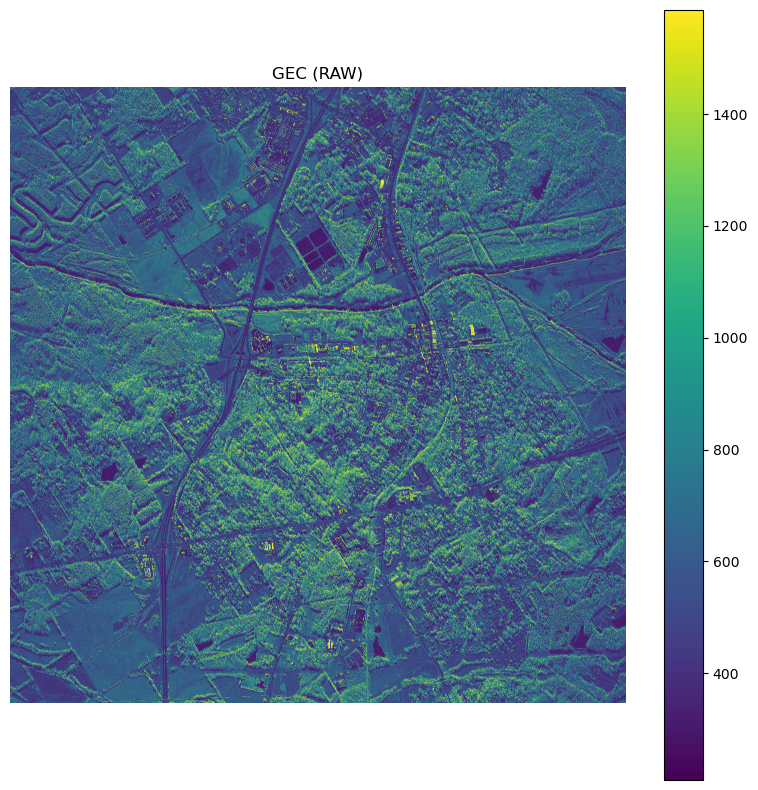

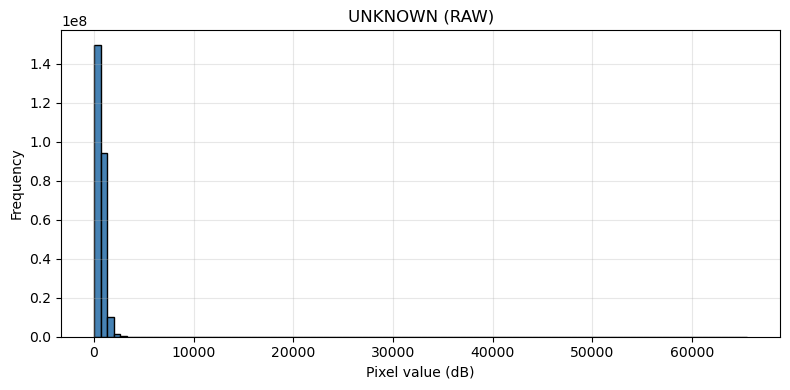

✓ Plotted 2026-01-28-17-38-00_UMBRA-10_GEC.tif

Displaying: 202601_Umbra-10_beta02026-01-28T17:38:00Z_filtered.tif
202601_Umbra-10_beta02026-01-28T17:38:00Z_filtered.tif min: -25.0 max: 10.0 mean: -6.995709096968954 std: 6.589496830990662


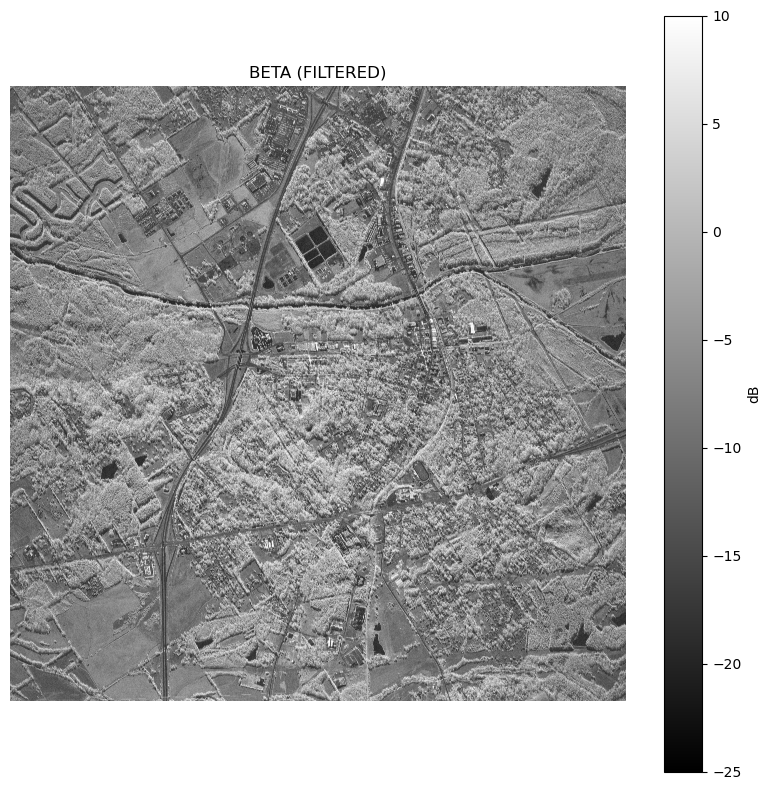

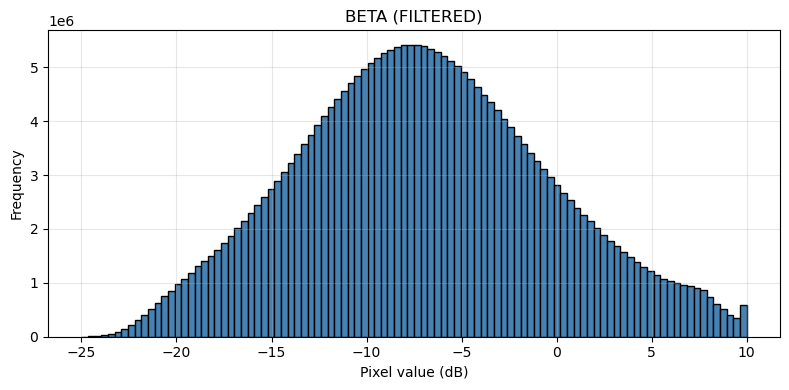

✓ Plotted 202601_Umbra-10_beta02026-01-28T17:38:00Z_filtered.tif

Displaying: 202601_Umbra-10_sigma02026-01-28T17:38:00Z_filtered.tif
202601_Umbra-10_sigma02026-01-28T17:38:00Z_filtered.tif min: -25.0 max: 10.0 mean: -6.9957090496238274 std: 6.589496804390484


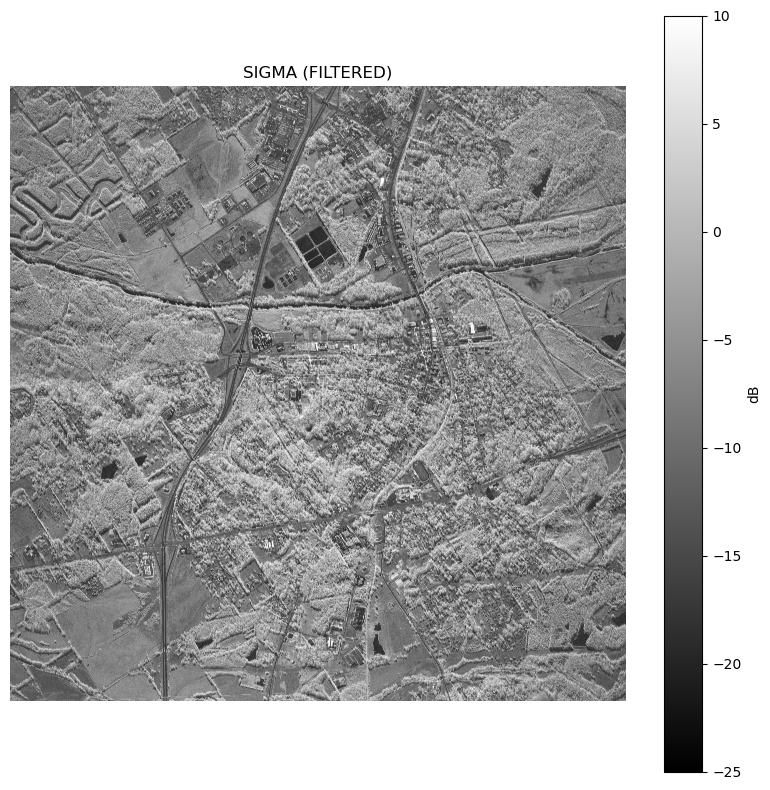

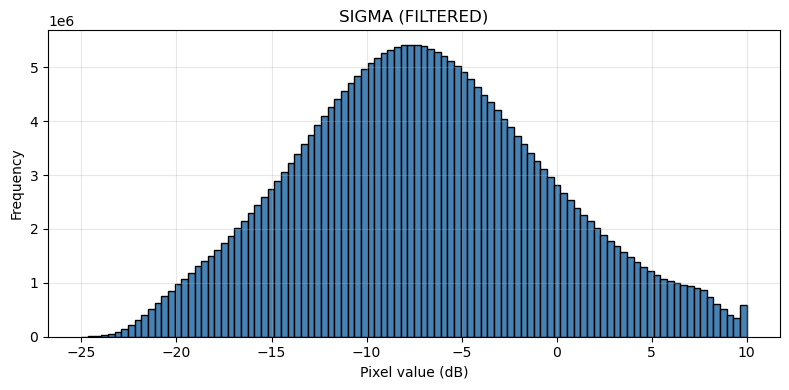

✓ Plotted 202601_Umbra-10_sigma02026-01-28T17:38:00Z_filtered.tif

File Details:

s3_temp:
  - 2026-01-28-17-38-00_UMBRA-10_GEC.tif (584.3 MB)
  - 202601_Umbra-10_beta02026-01-28T17:38:00Z_filtered.tif (1167.1 MB)
  - 202601_Umbra-10_sigma02026-01-28T17:38:00Z_filtered.tif (1167.1 MB)
  - 20260424_224158_273_SN46_L1D_SR_MS_CLOUD_0.tif (4.4 MB)
  - 20260424_224158_273_SN46_L1D_SR_MS_TOA_0.tif (2085.7 MB)
  - 202604_Capella-18_sigma02026-04-18T19:33:05Z_filtered.tif (520.6 MB)
  - CAPELLA_C18_SM_GEO_HH_20260418193305_20260418193309.tif (232.3 MB)


In [12]:
import glob
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np

output_dir = os.path.abspath(OUTPUT_DIR)

def parse_product_name(filename):
    name = filename.lower()

    if "sigma" in name:
        return "sigma"
    elif "beta" in name:
        return "beta"
    elif "gamma" in name:
        return "gamma"
    elif "rcs" in name:
        return "rcs"
    else:
        return "unknown"


def get_cmap(product):
    # SAR products are typically displayed in grayscale
    if product in ["sigma", "beta", "gamma", "rcs"]:
        return "gray"
    return "viridis"


if output_dir:
    print(f"✓ Found output directory: {output_dir}\n")

    tif_files = sorted([
        f for f in glob.glob(os.path.join(output_dir, "**/*.tif"), recursive=True)
        if not f.endswith(".tmp.tif")
    ])

    if tif_files:
        product_types = {}

        for tif_file in tif_files:
            product_type = os.path.basename(os.path.dirname(tif_file))
            product_types.setdefault(product_type, []).append(tif_file)

        print(f"Displaying {len(product_types)} product groups...\n")

        for tif_file in tif_files:
            if 'umbra' in tif_file.lower():
                print(f"\nDisplaying: {os.path.basename(tif_file)}")
    
                product = parse_product_name(tif_file)
                cmap = get_cmap(product)
    
                is_filtered = "filter" in tif_file.lower()
    
                with rasterio.open(tif_file) as src:
                    arr = src.read(1).astype(float)
    
    
                    print(
                        os.path.basename(tif_file),
                        "min:", np.nanmin(arr),
                        "max:", np.nanmax(arr),
                        "mean:", np.nanmean(arr),
                        "std:", np.nanstd(arr)
                    )
                    
                    # Percentile stretch for raw GEC
                    if product.upper() == 'UNKNOWN':
                        vmin, vmax = np.nanpercentile(arr, (2, 98))
                    else:
                        vmin, vmax = np.nanpercentile(arr, (0, 100))
    
                    plt.figure(figsize=(8, 8))
    
                    im = plt.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
                    cbar = plt.colorbar(im)
                    cbar.set_label('dB' if (product.upper() != 'UNKNOWN') else '')
    
                    title = f"{product.upper() if (product.upper() != 'UNKNOWN') else 'GEC'} {'(FILTERED)' if is_filtered else '(RAW)'}"
                    plt.title(title)
    
                    plt.axis("off")
                    plt.tight_layout()
                    plt.show()
    
                    # -----------------------------
                    # Histogram of pixel values
                    # -----------------------------
                    valid = arr[np.isfinite(arr)]
                    
                    plt.figure(figsize=(8, 4))
                    
                    plt.hist(valid.flatten(), bins=100, color="steelblue", edgecolor="black")
                    
                    plt.title(f"{product.upper()} {'(FILTERED)' if is_filtered else '(RAW)'}")
                    plt.xlabel("Pixel value (dB)")
                    plt.ylabel("Frequency")
                    
                    plt.grid(alpha=0.3)
                    plt.tight_layout()
                    plt.show()
    
                    print(f"✓ Plotted {os.path.basename(tif_file)}")
            else:
                continue

        # -----------------------------
        # File summary
        # -----------------------------
        print("\nFile Details:")
        print("=" * 50)

        for p_type, files in sorted(product_types.items()):
            print(f"\n{p_type}:")
            for f in files:
                size = os.path.getsize(f) / (1024 * 1024)
                print(f"  - {os.path.basename(f)} ({size:.1f} MB)")

    else:
        print("No finished GeoTIFF files found. Check processing output.")
else:
    print("Output directory not found.")

# Interactive Visualization

Using the leafmap package, we can visualize a file on a map projection with pan and zoom capabilities. With this, we can see the high-resolution details of Umbra, analyze the effects of the lee filter (which smoothes data), and view the geolocation of the file.

In [13]:
! pip install leafmap
! pip install localtileserver

In [14]:
import leafmap
m = leafmap.Map()
m.add_raster(tif_files[1], layer_name="SAR") # adjust index in tif_files[_] to change file being viewed
m

CommBridge()

Map(center=[34.485096, -89.0104], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', …

# Next Steps #

You can now:
1. Load and visualize the GeoTIFF files using libraries like `rasterio` or `GDAL`
2. Upload the COG files to cloud storage (S3, GCS, etc.)
3. Process additional dates or tiles by modifying the configuration variables
4. Generate additional products by updating the `PRODUCTS` list